(chap-aihc-data-resources)=
# Healthcare Data and Resources: From Clinical Events to Model-Ready Representations
**Content creators:** [Abhishek](https://github.com/moturuab)

Healthcare data are not a single spreadsheet. A patient journey may be represented across registration tables, laboratory results, medication orders, notes, device signals, images, and claims—each with different timing, units, identifiers, missingness, and governance constraints. This tutorial shows how to reason about those differences before choosing a model.

## At a glance

| Item | What this tutorial covers |
|---|---|
| Core question | How do we turn heterogeneous healthcare records into well-defined, traceable learning examples? |
| Linked teaching cohort | Intentionally simulated patients, encounters, observations, codes, notes, and waveforms |
| Real imaging example | **Official BreastMNIST only**, using its published train/validation/test partitions |
| Representation ladder | Raw event tables → checked windows/tensors/text matrices → weak and stronger image representations |
| Standards/resources | FHIR, DICOM, OMOP CDM, MIMIC-IV, PhysioNet, All of Us, and MedMNIST |
| Runtime | About 30–35 minutes for the core, including the compact image ladder |
| Hardware | CPU is sufficient; the tiny CNN can use a GPU if available |

:::{admonition} 30-minute core route
:class: tip
Work through Sections 1–9 to build and audit linked representations, then Sections 10–11 to inspect the official BreastMNIST data and compare the full image-model ladder. If time is short, read the stored CNN output rather than retraining it. Sections 12–14 are reference material for standards, resources, and project planning; Section 15 closes the tutorial.
:::

### Learning objectives

By the end, you should be able to:

1. distinguish the unit of observation from the unit of prediction;
2. identify the metadata required to interpret tabular, text, waveform, and image arrays;
3. preserve patient–encounter linkage and event time while transforming modalities;
4. detect leakage caused by post-index data or transformations fitted before splitting;
5. explain what interoperability standards do—and do not—solve; and
6. choose an appropriate public resource without overstating what a benchmark demonstrates.

:::{admonition} Two datasets with different purposes
:class: important
The linked electronic-record example is simulated so it can contain several modalities and deliberate data-quality defects without exposing anyone's information. The BreastMNIST section uses a real public benchmark distributed by MedMNIST. **The BreastMNIST images are not linked to the simulated patients or encounters.** They answer a separate educational question about image representation and official splits.
:::


## 1. Start with the decision, index time, and unit of analysis

Before inspecting files, write down the learning example you want to construct. Suppose the teaching task is to create a snapshot four hours after admission for each inpatient encounter. The eventual model might estimate a future outcome, but this notebook focuses on data construction rather than clinical prediction.

Three units are easy to confuse:

- A **patient** is a person and may have multiple encounters.
- An **encounter** is an episode of care and may contain many measurements, notes, or orders.
- An **observation** is one recorded event, such as a heart-rate measurement at a specific time.

If an encounter is the prediction unit, repeated observations must be summarized or represented within an explicitly bounded window. Counting every observation row as an independent patient would inflate sample size and mix information from the same episode across splits.

The next code-generated diagram makes the linkage and time boundary explicit without requiring a separate website extension.


In [1]:
# Core libraries used for the linked-data portion of the tutorial.
# The imaging section imports MedMNIST and PyTorch separately so that learners
# can see exactly which dependencies belong to that optional extension.
SEED = 2026

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit

rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)


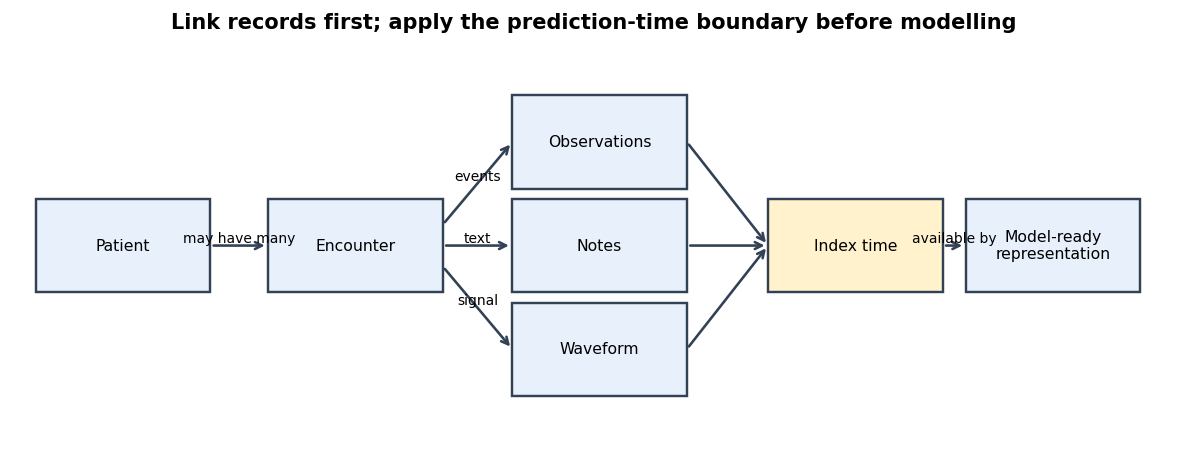

In [2]:
# Draw the data lineage as a self-contained Matplotlib figure. The arrows show
# relationships and eligibility rules; they do not imply causal effects.
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.axis("off")

boxes = {
    "Patient": (0.02, 0.58),
    "Encounter": (0.22, 0.58),
    "Observations": (0.43, 0.78),
    "Notes": (0.43, 0.58),
    "Waveform": (0.43, 0.38),
    "Index time": (0.65, 0.58),
    "Model-ready\nrepresentation": (0.82, 0.58),
}

# Keep box sizes fixed so learners can follow the topology at a glance.
for label, (x, y) in boxes.items():
    ax.add_patch(plt.Rectangle(
        (x, y - 0.09), 0.15, 0.18,
        facecolor="#e8f1fb" if label != "Index time" else "#fff2cc",
        edgecolor="#334155", linewidth=1.4,
    ))
    ax.text(x + 0.075, y, label, ha="center", va="center", fontsize=9)

def arrow(start, end, label=""):
    '''Add one labelled directional relationship between box edges.'''
    ax.annotate("", xy=end, xytext=start,
                arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#334155"})
    if label:
        midpoint = ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2)
        ax.text(*midpoint, label, fontsize=8, ha="center", va="bottom")

arrow((0.17, 0.58), (0.22, 0.58), "may have many")
arrow((0.37, 0.62), (0.43, 0.78), "events")
arrow((0.37, 0.58), (0.43, 0.58), "text")
arrow((0.37, 0.54), (0.43, 0.38), "signal")
for y in [0.78, 0.58, 0.38]:
    arrow((0.58, y), (0.65, 0.58))
arrow((0.80, 0.58), (0.82, 0.58), "available by")

ax.set_xlim(0, 1)
ax.set_ylim(0.2, 0.98)
ax.set_title("Link records first; apply the prediction-time boundary before modelling",
             fontweight="bold")
plt.show()


## 2. A modality is more than an array shape

The same numerical shape can mean very different things. A `(240, 200)` matrix might represent 240 encounters by 200 laboratory features, 240 short signals with 200 time points, or 240 notes embedded into 200 dimensions. Interpretation requires metadata and provenance.

| Modality | Natural structure | Metadata that must travel with it | Common risks |
|---|---|---|---|
| Demographics/encounters | One row per patient or encounter | Identifiers, dates, site, source system, version | Duplicates, stale fields, inconsistent definitions |
| Labs/vital signs | Long event table | Code, value, unit, specimen/device, timestamp, reference range | Unit errors, repeated values, informative missingness |
| Diagnoses/procedures | Sparse coded events | Coding system/version, position, present-on-admission status, time | Upcoding, rule changes, future codes |
| Medications | Orders, administrations, or dispensations | Drug code, dose, route, status, start/stop time | Confusing order with administration; dose normalization |
| Clinical text | Variable-length documents | Author role, note type, creation/sign time, amendments | Copied text, identifiers, post-outcome documentation |
| Waveforms | Channel × time arrays | Sampling rate, lead/channel, filter, device, clock alignment | Dropout, artifacts, resampling, device shift |
| Medical images | 2D/3D/4D arrays or series | Modality, anatomy, acquisition protocol, orientation, patient/study/series IDs | Leakage across images, metadata identifiers, protocol shift |

The “raw” data are also products of care processes. A missing laboratory result may mean that a clinician did not order the test, the patient was too unstable for collection, a result was delayed, or the feed failed. Treating every missing value as a random blank discards that context.


## 3. Why simulate the linked teaching cohort?

A realistic multi-table health record cannot normally be redistributed in a public notebook. Simulating the linked cohort lets us demonstrate identifiers, timestamps, inconsistent units, late notes, duplicates, and signal alignment without revealing protected information. It also keeps the notebook fast and deterministic.

This simulation is a **data-engineering exercise**, not a patient model. Its documentation patterns are authored, far simpler than real clinical systems, and not representative of any hospital. Any counts, missingness rates, or plots from this section are properties of the code below only.


In [3]:
# Patient table --------------------------------------------------------------
# We create stable opaque identifiers rather than using names or medical-record
# numbers. Real projects still need an approved linkage and de-identification plan.
n_patients = 240
patient_ids = np.array([f"PT-{i:04d}" for i in range(n_patients)])

patients = pd.DataFrame({
    "patient_id": patient_ids,
    "birth_year": rng.integers(1935, 2005, size=n_patients),
    "recorded_sex": rng.choice(["female", "male", "unknown"], n_patients, p=[0.50, 0.48, 0.02]),
    "home_region": rng.choice(["urban", "suburban", "rural"], n_patients, p=[0.62, 0.25, 0.13]),
})

# Encounter table ------------------------------------------------------------
# This compact example gives each patient one encounter, but the encounter_id
# remains distinct because production systems almost always allow repeat visits.
admit_offsets = rng.integers(0, 365, size=n_patients)
admit_times = pd.Timestamp("2025-01-01", tz="UTC") + pd.to_timedelta(admit_offsets, unit="D")

encounters = pd.DataFrame({
    "encounter_id": [f"ENC-{i:04d}" for i in range(n_patients)],
    "patient_id": patient_ids,
    "site": rng.choice(["Hospital-A", "Hospital-B"], n_patients, p=[0.58, 0.42]),
    "service": rng.choice(["medicine", "surgery", "cardiology"], n_patients, p=[0.48, 0.30, 0.22]),
    "admit_time": admit_times,
})

# The prediction boundary is defined once and stored. Downstream code should
# join to this column instead of recomputing a slightly different index time.
encounters["index_time"] = encounters["admit_time"] + pd.Timedelta(hours=4)

# Validate relationship cardinality before generating child tables.
assert patients["patient_id"].is_unique
assert encounters["encounter_id"].is_unique
assert encounters["patient_id"].isin(patients["patient_id"]).all()

encounters.head()


,encounter_id,patient_id,site,service,admit_time,index_time
0,ENC-0000,PT-0000,Hospital-B,surgery,2025-10-15 00:00:00+00:00,2025-10-15 04:00:00+00:00
1,ENC-0001,PT-0001,Hospital-B,medicine,2025-07-14 00:00:00+00:00,2025-07-14 04:00:00+00:00
2,ENC-0002,PT-0002,Hospital-B,medicine,2025-03-03 00:00:00+00:00,2025-03-03 04:00:00+00:00
3,ENC-0003,PT-0003,Hospital-B,medicine,2025-10-04 00:00:00+00:00,2025-10-04 04:00:00+00:00
4,ENC-0004,PT-0004,Hospital-B,cardiology,2025-07-08 00:00:00+00:00,2025-07-08 04:00:00+00:00


**Reading the table.** `patient_id` supports person-level grouping; `encounter_id` supports episode-level linkage; `admit_time` records the workflow event; and `index_time` records the prediction boundary. UTC-aware timestamps reduce, but do not eliminate, clock problems. Source systems may store local time, daylight-saving changes, delayed interfaces, or timestamp semantics such as order time versus result time.


## 4. Build a long observation table—with defects we can detect

Long format stores one measurement per row. It preserves the code, time, value, and unit, but it does not yet provide one row per encounter. We generate three vital signs over the first six hours, then introduce an impossible oxygen saturation, a Fahrenheit temperature, an exact duplicate, and a late measurement. The point is to retain defects visibly rather than silently cleaning the source table.


In [4]:
vital_specs = {
    # code: (central value, patient-level variability, measurement noise, unit)
    "heart_rate": (82.0, 12.0, 4.0, "beats/min"),
    "temperature": (37.0, 0.45, 0.15, "degC"),
    "oxygen_saturation": (96.0, 1.8, 0.7, "%"),
}

observation_rows = []
for encounter_index, encounter in encounters.iterrows():
    # A patient-specific deviation creates correlation across repeated values.
    # Without it, every measurement would be independent and unrealistically neat.
    for code_name, (centre, between_sd, within_sd, unit) in vital_specs.items():
        patient_level = rng.normal(centre, between_sd)
        for hour in [0.5, 2.0, 3.5, 5.5]:
            observation_rows.append({
                "patient_id": encounter["patient_id"],
                "encounter_id": encounter["encounter_id"],
                "observed_time": encounter["admit_time"] + pd.Timedelta(hours=hour),
                "code": code_name,
                "value": round(patient_level + rng.normal(0, within_sd), 2),
                "unit": unit,
                "source_system": "bedside-monitor" if code_name != "temperature" else "nursing-flow-sheet",
            })

observations = pd.DataFrame(observation_rows)

# Deliberate defects. Keeping these edits explicit makes each later rule testable.
# Row 8 is the first oxygen-saturation event; row 5 is an early temperature.
observations.loc[8, ["value", "unit"]] = [104.0, "%"]             # impossible SpO2
observations.loc[5, ["value", "unit"]] = [98.6, "degF"]           # convertible unit
observations = pd.concat([observations, observations.iloc[[20]]], ignore_index=True)  # exact duplicate

# One heart-rate result arrives after the four-hour boundary and must not enter
# the index-time feature representation, even though it belongs to the encounter.
late_row = observations.iloc[[32]].copy()
late_encounter = encounters.loc[encounters["encounter_id"] == late_row.iloc[0]["encounter_id"]].iloc[0]
late_row["observed_time"] = late_encounter["index_time"] + pd.Timedelta(minutes=40)
observations = pd.concat([observations, late_row], ignore_index=True)

observations.head(8)


,patient_id,encounter_id,observed_time,code,value,unit,source_system
0,PT-0000,ENC-0000,2025-10-15 00:30:00+00:00,heart_rate,74.56,beats/min,bedside-monitor
1,PT-0000,ENC-0000,2025-10-15 02:00:00+00:00,heart_rate,70.23,beats/min,bedside-monitor
2,PT-0000,ENC-0000,2025-10-15 03:30:00+00:00,heart_rate,74.99,beats/min,bedside-monitor
3,PT-0000,ENC-0000,2025-10-15 05:30:00+00:00,heart_rate,78.09,beats/min,bedside-monitor
4,PT-0000,ENC-0000,2025-10-15 00:30:00+00:00,temperature,36.49,degC,nursing-flow-sheet
5,PT-0000,ENC-0000,2025-10-15 02:00:00+00:00,temperature,98.60,degF,nursing-flow-sheet
6,PT-0000,ENC-0000,2025-10-15 03:30:00+00:00,temperature,36.52,degC,nursing-flow-sheet
7,PT-0000,ENC-0000,2025-10-15 05:30:00+00:00,temperature,36.36,degC,nursing-flow-sheet


**Reading the output.** The value `98.6` is not intrinsically valid or invalid; its meaning depends on the unit. Similarly, the late heart rate is a legitimate event in the raw record but ineligible for a representation at the four-hour index time. Cleaning therefore needs domain rules *and* the intended-use timeline.

Production systems should preserve raw values and record derived corrections, exclusions, and rule versions separately. Overwriting source data makes later audit and error investigation difficult.


## 5. Add notes, codes, and waveforms while preserving linkage

The next cell constructs three different storage patterns:

- notes and codes remain event tables with timestamps;
- waveforms are stored in a dense NumPy array for efficient modelling; and
- a separate index table maps each array position back to its patient and encounter.

Arrays do not carry clinical identifiers or timing semantics on their own. Losing the index table would make the signals uninterpretable and potentially misaligned.


In [5]:
# Timestamped notes ----------------------------------------------------------
note_templates = {
    "medicine": "Admitted for medical assessment. Symptoms stable at initial review.",
    "surgery": "Post-operative admission. Pain plan and mobility review documented.",
    "cardiology": "Admitted for cardiac monitoring. Initial rhythm review completed.",
}
notes = encounters[["patient_id", "encounter_id", "service", "admit_time", "index_time"]].copy()
notes["note_type"] = "admission-note"
notes["created_time"] = notes["admit_time"] + pd.to_timedelta(rng.uniform(1.0, 3.5, n_patients), unit="h")
notes["text"] = notes["service"].map(note_templates)

# One note is signed after the index time and will be excluded from the snapshot.
notes.loc[5, "created_time"] = notes.loc[5, "index_time"] + pd.Timedelta(minutes=25)

# Coded events ---------------------------------------------------------------
codes = encounters[["patient_id", "encounter_id", "admit_time"]].copy()
codes["code_system"] = "ICD-10-CA (illustrative code strings)"
codes["code"] = rng.choice(["I10", "E11.9", "J18.9", "Z98.89"], n_patients)
codes["recorded_time"] = codes["admit_time"] + pd.to_timedelta(rng.uniform(0.5, 3.0, n_patients), unit="h")

# Waveform-like teaching signals --------------------------------------------
# These are non-clinical sinusoids with noise; they are not ECG recordings.
sampling_rate_hz = 25
n_seconds = 8
time_axis = np.arange(sampling_rate_hz * n_seconds) / sampling_rate_hz
signals = np.empty((n_patients, 1, len(time_axis)), dtype=np.float32)

for i in range(n_patients):
    frequency = rng.uniform(0.8, 1.4)
    phase = rng.uniform(0, 2 * np.pi)
    signals[i, 0] = np.sin(2 * np.pi * frequency * time_axis + phase) + rng.normal(0, 0.15, len(time_axis))

signal_index = encounters[["patient_id", "encounter_id", "index_time"]].copy()
signal_index["array_row"] = np.arange(n_patients)
signal_index["channel"] = "fictional-signal"
signal_index["sampling_rate_hz"] = sampling_rate_hz

print("Notes:", notes.shape, "Codes:", codes.shape)
print("Signals [encounter, channel, time]:", signals.shape)
signal_index.head(3)


Notes: (240, 8) Codes: (240, 6)
Signals [encounter, channel, time]: (240, 1, 200)


,patient_id,encounter_id,index_time,array_row,channel,sampling_rate_hz
0,PT-0000,ENC-0000,2025-10-15 04:00:00+00:00,0,fictional-signal,25
1,PT-0001,ENC-0001,2025-07-14 04:00:00+00:00,1,fictional-signal,25
2,PT-0002,ENC-0002,2025-03-03 04:00:00+00:00,2,fictional-signal,25


**How to read the shapes.** `signals.shape == (240, 1, 200)` means 240 encounter-indexed examples, one channel, and 200 samples. The values alone do not reveal that the sampling rate is 25 Hz, that the duration is eight seconds, or that the signals are fictional. Those facts live in metadata and documentation.

The four modality tables are linked because their identifiers refer to the same simulated encounters. This does **not** imply that every real system exposes clean, stable keys. Cross-system enterprise identifiers, merged records, duplicate patients, and encounter reassignment require explicit reconciliation and audit.


## 6. Validate linkage and time before representation

Data validation should fail loudly when structural assumptions are violated. The checks below cover cardinality, orphaned records, duplicates, units, ranges, and index-time eligibility. They are deliberately readable; a production implementation might use a validation framework, but the clinical rules still need to be specified by people.


In [6]:
# Relationship checks --------------------------------------------------------
known_encounters = set(encounters["encounter_id"])
linkage_checks = pd.Series({
    "unique patient IDs": patients["patient_id"].is_unique,
    "unique encounter IDs": encounters["encounter_id"].is_unique,
    "orphan observation encounters": (~observations["encounter_id"].isin(known_encounters)).sum(),
    "orphan note encounters": (~notes["encounter_id"].isin(known_encounters)).sum(),
    "orphan code encounters": (~codes["encounter_id"].isin(known_encounters)).sum(),
    "duplicate observation rows": observations.duplicated().sum(),
})

# Add the index time to each event row without dropping the raw event timestamp.
obs_checked = observations.merge(
    encounters[["encounter_id", "index_time"]], on="encounter_id", how="left", validate="many_to_one"
)
obs_checked["available_by_index"] = obs_checked["observed_time"] <= obs_checked["index_time"]

# Unit and range rules are feature-specific. These thresholds are illustrative
# teaching rules, not a substitute for a validated clinical data dictionary.
allowed_units = {
    "heart_rate": {"beats/min"},
    "temperature": {"degC", "degF"},
    "oxygen_saturation": {"%"},
}
ranges = {
    "heart_rate": (20, 250),
    "temperature": (30, 45),       # applied after conversion to degrees C
    "oxygen_saturation": (40, 100),
}

obs_checked["unit_allowed"] = [unit in allowed_units[code] for code, unit in zip(obs_checked["code"], obs_checked["unit"])]
obs_checked["value_canonical"] = obs_checked["value"]
fahrenheit = (obs_checked["code"] == "temperature") & (obs_checked["unit"] == "degF")
obs_checked.loc[fahrenheit, "value_canonical"] = (obs_checked.loc[fahrenheit, "value"] - 32) * 5 / 9
obs_checked.loc[fahrenheit, "unit"] = "degC"

obs_checked["range_allowed"] = [
    ranges[code][0] <= value <= ranges[code][1]
    for code, value in zip(obs_checked["code"], obs_checked["value_canonical"])
]

quality_summary = pd.concat([
    linkage_checks,
    pd.Series({
        "post-index observations": int((~obs_checked["available_by_index"]).sum()),
        "disallowed units": int((~obs_checked["unit_allowed"]).sum()),
        "out-of-range values": int((~obs_checked["range_allowed"]).sum()),
        "post-index notes": int((notes["created_time"] > notes["index_time"]).sum()),
    }),
])
quality_summary.to_frame("value")


,value
unique patient IDs,True
unique encounter IDs,True
orphan observation encounters,0
orphan note encounters,0
orphan code encounters,0
duplicate observation rows,1
post-index observations,721
disallowed units,0
out-of-range values,14
post-index notes,1


**Interpretation of this run.** The audit reports **721 post-index observations**: the 720 routinely generated measurements at hour 5.5 plus the one deliberately appended result 40 minutes after the index. It also finds **one exact duplicate, 14 out-of-range values, one post-index note, and no orphan records or disallowed units**. One impossible oxygen saturation was inserted deliberately; the other high values arise because an unconstrained Gaussian teaching generator can exceed the 100% ceiling. That is itself a useful data-generation check. The Fahrenheit temperature is allowed because it can be converted explicitly to Celsius before range checking. These counts are properties of this seeded simulation, not estimates of real hospital data quality.

A quality flag is not automatically a deletion command. An out-of-range value may be a true extreme, a unit error, a device artifact, or a mapping error. The appropriate response depends on provenance and intended use. Here we exclude invalid or late values only from the derived teaching representation, while retaining the source rows and flags for audit.

Important production additions include terminology validation, allowable temporal order, reference-range context, source-to-target row reconciliation, timestamp latency, amendment handling, device identifiers, and trends by site and subgroup.


## 7. Split by patient before learning any representation

Learned transformations can leak too. A text vocabulary fitted on all notes uses information about which words occur in the test partition, even if outcome labels are hidden. The safe pattern is:

1. assign patients to partitions;
2. filter each modality using the same patient assignment;
3. fit imputers, vocabularies, scalers, or embeddings on training data only; and
4. transform validation/test data using the already-fitted training object.

We demonstrate this with TF–IDF. The goal is representation, not a clinical text classifier.


In [7]:
# GroupShuffleSplit assigns whole patients, so every linked modality for one
# patient remains on the same side of the boundary. In this teaching cohort
# there is one encounter per patient; the rule remains correct if repeats appear.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_rows, test_rows = next(splitter.split(encounters, groups=encounters["patient_id"]))
train_patient_ids = set(encounters.iloc[train_rows]["patient_id"])
test_patient_ids = set(encounters.iloc[test_rows]["patient_id"])
assert train_patient_ids.isdisjoint(test_patient_ids)

# Keep only notes that existed by the index time; a later-signed note belongs to
# the raw record but cannot be used for an index-time snapshot.
eligible_notes = notes.loc[notes["created_time"] <= notes["index_time"]].copy()
train_notes = eligible_notes[eligible_notes["patient_id"].isin(train_patient_ids)]
test_notes = eligible_notes[eligible_notes["patient_id"].isin(test_patient_ids)]

# fit_transform learns the vocabulary and inverse-document frequencies from
# training notes. transform reuses those fixed columns for test notes.
tfidf = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2)
X_text_train = tfidf.fit_transform(train_notes["text"])
X_text_test = tfidf.transform(test_notes["text"])

print("Training patients:", len(train_patient_ids), "Test patients:", len(test_patient_ids))
print("TF–IDF shapes [notes, training-learned terms]:", X_text_train.shape, X_text_test.shape)
print("Example terms:", tfidf.get_feature_names_out()[:12].tolist())


Training patients: 180 Test patients: 60
TF–IDF shapes [notes, training-learned terms]: (180, 37) (59, 37)
Example terms: ['admission', 'admission pain', 'admitted', 'admitted cardiac', 'admitted medical', 'assessment', 'assessment symptoms', 'cardiac', 'cardiac monitoring', 'completed', 'documented', 'initial']


**Interpretation.** Training and test matrices have exactly the same columns because the test notes are projected into the training vocabulary. A new test-only phrase is ignored instead of expanding the representation. If a pretrained language model were used, its version, pretraining corpus, tokenization, local adaptation, and frozen/fine-tuned status would become part of the provenance record.


## 8. Convert observations into an encounter-by-time tensor

Deep sequence models often expect a dense tensor, but electronic records are irregular event streams. The code below defines four one-hour bins before the index time and stores both values and observation masks. The mask distinguishes “no eligible measurement” from a measured zero.

Choices about bin width, aggregation, carry-forward, and missingness indicators encode assumptions. They should be justified from the clinical workflow and evaluated, not treated as neutral formatting.


In [8]:
# Use only rows that are timely, have an allowed unit, pass the illustrative
# range rule, and are not exact duplicates. The raw obs_checked table is kept.
eligible_obs = obs_checked.loc[
    obs_checked["available_by_index"]
    & obs_checked["unit_allowed"]
    & obs_checked["range_allowed"]
].drop_duplicates(subset=["patient_id", "encounter_id", "observed_time", "code", "value_canonical"])

eligible_obs = eligible_obs.merge(
    encounters[["encounter_id", "admit_time"]], on="encounter_id", how="left", validate="many_to_one"
)
eligible_obs["hour_from_admission"] = (
    eligible_obs["observed_time"] - eligible_obs["admit_time"]
).dt.total_seconds() / 3600
eligible_obs["hour_bin"] = pd.cut(
    eligible_obs["hour_from_admission"], bins=[0, 1, 2, 3, 4], labels=[0, 1, 2, 3], include_lowest=True
)

vital_order = ["heart_rate", "temperature", "oxygen_saturation"]
encounter_order = encounters["encounter_id"].tolist()
encounter_position = {encounter_id: i for i, encounter_id in enumerate(encounter_order)}
vital_position = {vital: i for i, vital in enumerate(vital_order)}

# Shape convention: [encounter, time bin, variable]. NaN means no valid value.
vital_tensor = np.full((len(encounter_order), 4, len(vital_order)), np.nan, dtype=np.float32)
observation_mask = np.zeros_like(vital_tensor, dtype=bool)

grouped = eligible_obs.groupby(["encounter_id", "hour_bin", "code"], observed=True)["value_canonical"].mean()
for (encounter_id, hour_bin, vital), value in grouped.items():
    i = encounter_position[encounter_id]
    t = int(hour_bin)
    j = vital_position[vital]
    vital_tensor[i, t, j] = value
    observation_mask[i, t, j] = True

print("Vital tensor [encounter, hour, variable]:", vital_tensor.shape)
print("Observed fraction by variable:")
print(pd.Series(observation_mask.mean(axis=(0, 1)), index=vital_order))


Vital tensor [encounter, hour, variable]: (240, 4, 3)
Observed fraction by variable:
heart_rate           0.75
temperature          0.75
oxygen_saturation    0.74
dtype: float64


**Interpretation.** The tensor is now model-compatible but less expressive than the event table: it averages repeated measurements within bins and discards exact timestamps. We preserve the long table so the transformation can be audited or changed. More sophisticated approaches can model time gaps directly, but they still need explicit handling of data latency, missingness, and the index-time boundary.


## 9. Visualize one fictional encounter across linked modalities

A multimodal example should be assembled through identifiers, not by assuming that row 12 of every file refers to the same person. We select an encounter ID, look up its observations, note, and indexed signal, then show their timelines together.


,encounter_id,created_time,text
12,ENC-0012,2025-06-07 01:06:07.064797903+00:00,Admitted for cardiac monitoring. Initial rhyth...


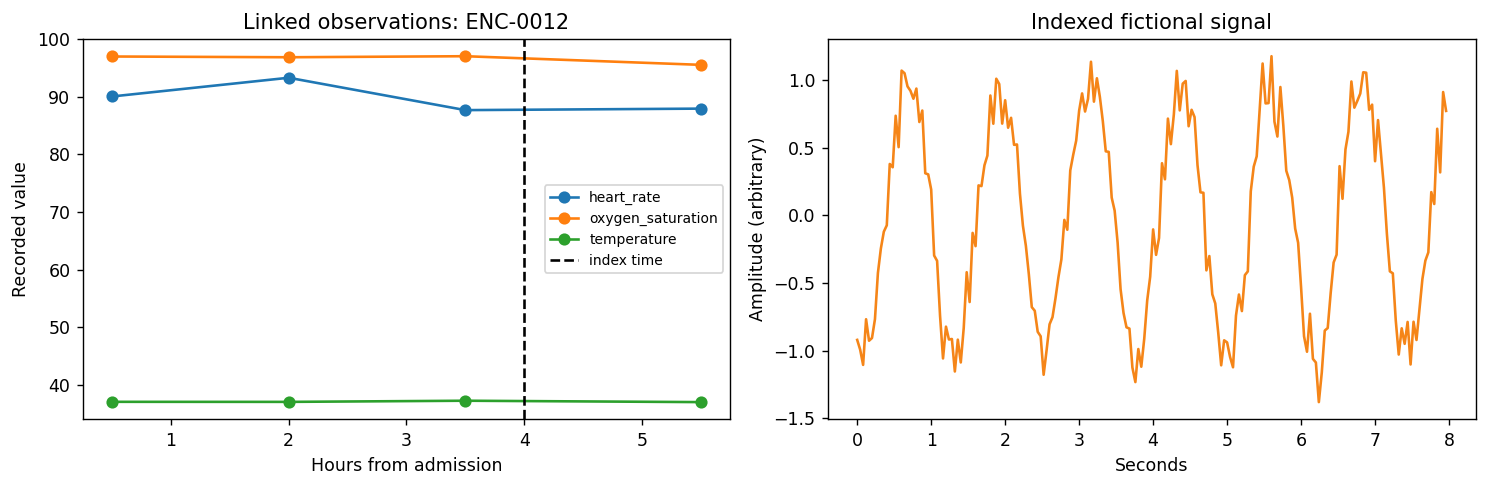

In [9]:
example_encounter = encounters.loc[12, "encounter_id"]
# Phase 1: retrieve records through the encounter key while leaving each
# modality in its native event-table or array representation.
example_meta = encounters.loc[encounters["encounter_id"] == example_encounter].iloc[0]
example_obs = obs_checked.loc[obs_checked["encounter_id"] == example_encounter]
example_note = notes.loc[notes["encounter_id"] == example_encounter]

# Use the explicit array_row mapping; never assume DataFrame row order still
# matches the array after filtering, sorting, or merging.
array_row = int(signal_index.loc[signal_index["encounter_id"] == example_encounter, "array_row"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for code_name, group in example_obs.groupby("code"):
    hours = (group["observed_time"] - example_meta["admit_time"]).dt.total_seconds() / 3600
    axes[0].plot(hours, group["value_canonical"], "o-", label=code_name)
axes[0].axvline(4, color="black", linestyle="--", label="index time")
axes[0].set(xlabel="Hours from admission", ylabel="Recorded value", title=f"Linked observations: {example_encounter}")
axes[0].legend(fontsize=8)

axes[1].plot(time_axis, signals[array_row, 0], color="#F58518")
axes[1].set(xlabel="Seconds", ylabel="Amplitude (arbitrary)", title="Indexed fictional signal")
plt.tight_layout()
plt.show()

example_note[["encounter_id", "created_time", "text"]]


**Interpretation.** The panels represent one fictional encounter only because the metadata join establishes that relationship. They do not prove that the events are causally related or equally trustworthy. A multimodal model can amplify linkage errors: a mislabeled image, note, or waveform may be technically valid yet belong to the wrong patient or time.


## 10. Real imaging resource: official BreastMNIST

BreastMNIST is a small 2D breast-ultrasound benchmark in MedMNIST. It contains 780 grayscale images resized to $28\times28$ pixels, with 546 training, 78 validation, and 156 test examples. In the official files, label `0` means **malignant** and label `1` means **normal/benign**. For the evaluation convention used here, we copy and invert the loaded labels so that `1` means malignant and `0` means normal/benign. This remapping changes neither the images nor membership in any official split. The standardized size and published splits make the dataset suitable for lightweight education.

It is **not** a deployment dataset. The images are heavily downsampled, the validation set is tiny, the label task is simplified, and benchmark performance does not establish clinical validity or generalization to another scanner, institution, population, or workflow.

The next cell uses only the official loader and splits. There is deliberately **no synthetic fallback**. If download access is unavailable, the cell stops with a clear error so that learners do not accidentally interpret invented geometry as medical imaging data.


In [10]:
# Run once in a fresh Colab runtime. Pinning the small dataset wrapper makes the
# loader and label metadata reproducible while leaving Colab's PyTorch intact.
%pip install -q "medmnist==3.0.2" "torch>=2.0" "torchvision>=0.15"


In [11]:
from pathlib import Path
import warnings

# Some locked-down runtimes cannot create MedMNIST's optional default cache
# directory. We provide an explicit writable root below, so suppress only that
# harmless import-time warning rather than hiding other warnings.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Failed to setup default root")
    import medmnist
    from medmnist import INFO, BreastMNIST

# The official loader downloads the published BreastMNIST archive and preserves
# its train/validation/test partitions. We never resplit or merge these sets.
data_root = Path("data/medmnist")
data_root.mkdir(parents=True, exist_ok=True)

breast_train = BreastMNIST(split="train", root=str(data_root), download=True)
breast_val = BreastMNIST(split="val", root=str(data_root), download=True)
breast_test = BreastMNIST(split="test", root=str(data_root), download=True)

breast_info = INFO["breastmnist"]
official_class_names = {int(key): value for key, value in breast_info["label"].items()}
# Downstream binary metrics conventionally treat label 1 as the event of
# interest. This analysis mapping makes malignant the positive class.
class_names = {0: "normal/benign", 1: "malignant"}

# Explicit assertions catch accidental use of a different dataset or split.
assert len(breast_train) == 546
assert len(breast_val) == 78
assert len(breast_test) == 156

print("Dataset:", breast_info["description"])
print("Task:", breast_info["task"])
print("Official splits:", {"train": len(breast_train), "validation": len(breast_val), "test": len(breast_test)})
print("Official labels:", official_class_names)
print("Analysis labels after documented inversion:", class_names)


Dataset: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
Task: binary-class
Official splits: {'train': 546, 'validation': 78, 'test': 156}
Official labels: {0: 'malignant', 1: 'normal, benign'}
Analysis labels after documented inversion: {0: 'normal/benign', 1: 'malignant'}


### Inspect images and labels before fitting a model

Visualization is a data check, not clinical interpretation. We verify the shape, intensity range, and class counts. A domain expert would additionally examine acquisition context, annotations, exclusions, duplicates, and whether multiple images come from the same patient.


Image array [sample, height, width]: (546, 28, 28)
Training label counts: {'normal/benign': 399, 'malignant': 147}


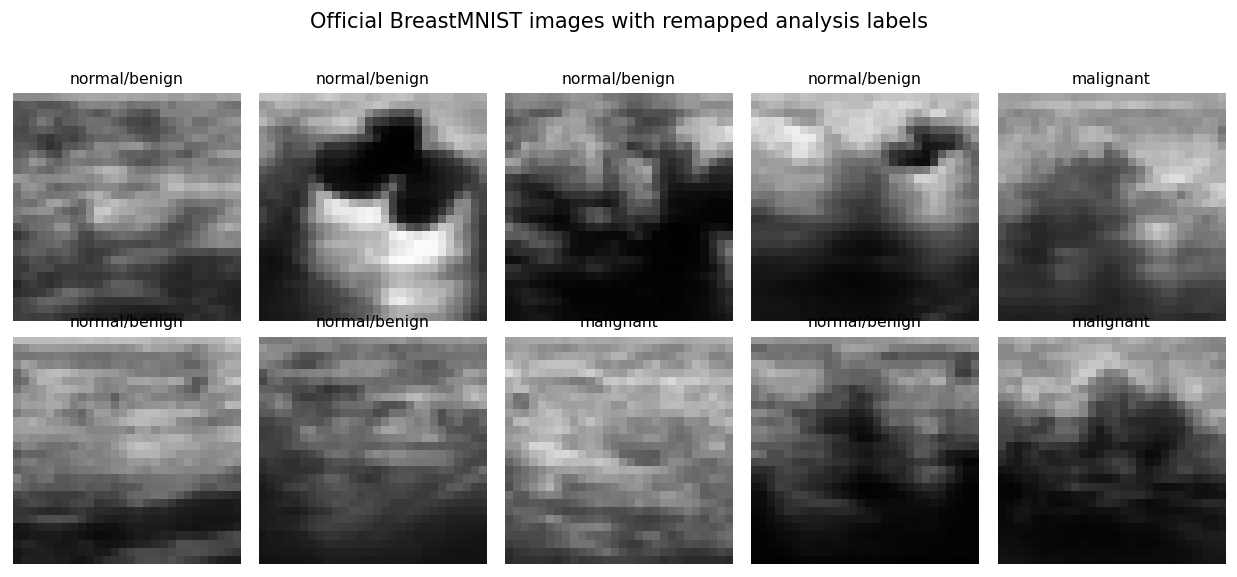

In [12]:
# Convert the small official dataset to NumPy arrays. PIL images become
# [sample, height, width] uint8 arrays; labels become one-dimensional integers.
def medmnist_to_numpy_with_malignant_positive(dataset):
    '''Copy official images and remap 0=malignant/1=normal-benign to 1/0.'''
    images = np.stack([np.asarray(dataset[i][0], dtype=np.uint8) for i in range(len(dataset))])
    official_labels = np.array([
        int(np.asarray(dataset[i][1]).reshape(-1)[0]) for i in range(len(dataset))
    ])
    # Binary inversion changes label semantics only. Dataset order and official
    # train/validation/test membership remain exactly as loaded.
    labels = 1 - official_labels
    assert set(np.unique(labels)).issubset({0, 1})
    return images, labels

X_img_train, y_img_train = medmnist_to_numpy_with_malignant_positive(breast_train)
X_img_val, y_img_val = medmnist_to_numpy_with_malignant_positive(breast_val)
X_img_test, y_img_test = medmnist_to_numpy_with_malignant_positive(breast_test)

# Phase 2: inspect widely spaced official training examples rather than
# cherry-picking especially easy or difficult images.
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, index in zip(axes.ravel(), np.linspace(0, len(X_img_train) - 1, 10, dtype=int)):
    ax.imshow(X_img_train[index], cmap="gray", vmin=0, vmax=255)
    ax.set_title(class_names[int(y_img_train[index])], fontsize=9)
    ax.axis("off")
fig.suptitle("Official BreastMNIST images with remapped analysis labels", y=1.02)
plt.tight_layout()
plt.show()

print("Image array [sample, height, width]:", X_img_train.shape)
print("Training label counts:", pd.Series(y_img_train).map(class_names).value_counts().to_dict())


## 11. Representation/model ladder: what information does each step retain?

This small ladder is included to connect data representation to model behaviour—not to chase a benchmark score.

1. A **majority baseline** ignores the pixels and predicts one probability.
2. A **global-summary logistic model** sees only mean, standard deviation, quantiles, and simple edge magnitude. It discards location and shape.
3. A **flattened-pixel logistic model** sees every pixel location but treats spatial relationships only through separate coefficients.
4. A **tiny convolutional neural network** shares local filters across the image and can learn spatial patterns. It is more flexible, but the training set is very small and improvement is not guaranteed.

We choose between model configurations on the 78-image validation set and open the official test set once. AUROC and AUPRC use the remapped target, so **malignant is the positive class** and the no-skill AUPRC reference is the malignant prevalence. Because validation is so small, differences of a few cases can reverse the ranking; repeated experiments or stronger claims need uncertainty estimates and a more appropriate study design.


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Phase 1: build a deliberately weak representation that discards lesion
# location and most spatial shape information.
def global_image_features(images):
    '''Create deliberately coarse, interpretable image summaries.

    Edge magnitude measures adjacent-pixel changes but discards where they occur.
    This weak representation helps show why spatial structure can matter.
    '''
    images_float = images.astype(np.float32) / 255.0
    horizontal_edge = np.abs(np.diff(images_float, axis=2)).mean(axis=(1, 2))
    vertical_edge = np.abs(np.diff(images_float, axis=1)).mean(axis=(1, 2))
    return np.column_stack([
        images_float.mean(axis=(1, 2)),
        images_float.std(axis=(1, 2)),
        np.quantile(images_float, 0.25, axis=(1, 2)),
        np.quantile(images_float, 0.50, axis=(1, 2)),
        np.quantile(images_float, 0.75, axis=(1, 2)),
        horizontal_edge,
        vertical_edge,
    ])

global_train = global_image_features(X_img_train)
global_val = global_image_features(X_img_val)
global_test = global_image_features(X_img_test)
flat_train = X_img_train.reshape(len(X_img_train), -1).astype(np.float32) / 255.0
flat_val = X_img_val.reshape(len(X_img_val), -1).astype(np.float32) / 255.0
flat_test = X_img_test.reshape(len(X_img_test), -1).astype(np.float32) / 255.0

image_candidates = {
    "Majority baseline": (
        DummyClassifier(strategy="prior"),
        np.zeros((len(X_img_train), 1)),
        np.zeros((len(X_img_val), 1)),
        np.zeros((len(X_img_test), 1)),
    ),
    "Global summaries + logistic": (
        make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=2000)),
        global_train, global_val, global_test,
    ),
    "Flattened pixels + logistic": (
        make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=3000)),
        flat_train, flat_val, flat_test,
    ),
}

# Phase 2: fit every representation/model combination on the official training
# split under the same validation metric contract.
image_validation_rows = []
fitted_image_candidates = {}
validation_probabilities = {}
for name, (model, train_representation, val_representation, _) in image_candidates.items():
    # Only the official training split is fitted. The official validation split
    # is used for comparison; the test labels have not entered this loop.
    model.fit(train_representation, y_img_train)
    probability = model.predict_proba(val_representation)[:, 1]
    fitted_image_candidates[name] = model
    validation_probabilities[name] = probability
    image_validation_rows.append({
        "model": name,
        "validation_AUROC": roc_auc_score(y_img_val, probability),
        "validation_AUPRC": average_precision_score(y_img_val, probability),
    })

pd.DataFrame(image_validation_rows).set_index("model")


,validation_AUROC,validation_AUPRC
model,,
Majority baseline,0.500,0.269
Global summaries + logistic,0.826,0.672
Flattened pixels + logistic,0.840,0.748


**How to interpret the ladder.** An improvement over the majority baseline shows that the representation contains some label-associated information in this benchmark. It does not show that the model recognizes pathology for the right reason. The flattened representation can overfit because it has 784 pixel features but only 546 training images. A convolutional model has a more appropriate spatial inductive bias, yet its extra flexibility can still hurt when data are scarce.

Do not rewrite the story if one run is not monotonic. “Stronger architecture” means better matched to image structure, not guaranteed better performance on a tiny validation sample.


### A tiny convolutional model

The final model in the core ladder keeps the network intentionally small. It trains with the official training split, checks AUROC on the official validation split after each epoch, restores the best validation state, and evaluates the official test split once. The goal is to expose tensor shapes and spatial modelling—not to claim state-of-the-art performance.


In [14]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Phase 1: learn intensity normalization from official training images only,
# then add the channel dimension expected by Conv2d: [N, 1, 28, 28].
training_pixel_mean = (X_img_train.astype(np.float32) / 255.0).mean()
training_pixel_std = (X_img_train.astype(np.float32) / 255.0).std()

def image_tensor(images):
    '''Scale, train-normalize, and reshape images to [N, 1, H, W].'''
    scaled = torch.tensor(images[:, None], dtype=torch.float32) / 255.0
    return (scaled - training_pixel_mean) / training_pixel_std

train_loader = DataLoader(
    TensorDataset(image_tensor(X_img_train), torch.tensor(y_img_train, dtype=torch.long)),
    batch_size=64, shuffle=True,
)
val_tensor = image_tensor(X_img_val).to(device)

class TinyBreastCNN(nn.Module):
    '''Small spatial model appropriate for 28×28 one-channel teaching images.'''
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 28×28 -> 14×14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 14×14 -> 7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 32×7×7 -> 1,568 features
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        features = self.features(x)
        return self.classifier(features)

cnn = TinyBreastCNN().to(device)
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
# Malignant images are the minority. A modest fixed relative weight prevents
# the training loss from being dominated by normal/benign examples.
malignant_weight = len(y_img_train) / (2 * y_img_train.sum())
loss_function = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, malignant_weight], dtype=torch.float32, device=device)
)

# Phase 2: train only on official training batches; validation AUROC controls
# state selection, while test labels remain untouched.
best_state, best_val_auc, patience_left = None, -np.inf, 3
history = []
for epoch in range(1, 13):
    cnn.train()
    epoch_losses = []
    for batch_images, batch_labels in train_loader:
        batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

        # Horizontal flipping is a small, label-preserving training augmentation.
        # It is applied only to training batches, never validation or test images.
        flip_mask = torch.rand(len(batch_images), device=device) < 0.5
        batch_images[flip_mask] = torch.flip(batch_images[flip_mask], dims=[3])

        optimizer.zero_grad()
        loss = loss_function(cnn(batch_images), batch_labels)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    # Validation is used for early stopping, never gradient updates.
    cnn.eval()
    with torch.no_grad():
        val_probability = torch.softmax(cnn(val_tensor), dim=1)[:, 1].cpu().numpy()
    val_auc = roc_auc_score(y_img_val, val_probability)
    history.append({"epoch": epoch, "train_loss": np.mean(epoch_losses), "validation_AUROC": val_auc})

    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = copy.deepcopy(cnn.state_dict())
        patience_left = 3
    else:
        patience_left -= 1
        if patience_left == 0:
            break

# Phase 3: restore the best validation state rather than the final epoch.
cnn.load_state_dict(best_state)
# Recompute probabilities from the restored state; `val_probability` from the
# loop belongs to the final attempted epoch, which may not be the selected one.
cnn.eval()
with torch.no_grad():
    best_val_probability = torch.softmax(cnn(val_tensor), dim=1)[:, 1].cpu().numpy()
pd.DataFrame(history)


,epoch,train_loss,validation_AUROC
0,1,0.659,0.757
1,2,0.579,0.805
2,3,0.529,0.840
3,4,0.498,0.854
4,5,0.505,0.879
5,6,0.467,0.867
6,7,0.429,0.873
7,8,0.432,0.895
8,9,0.391,0.891
9,10,0.366,0.901


In [15]:
# Open the official test set only after every representation, model,
# hyperparameter, and CNN stopping rule has been frozen using train/validation.
cnn.eval()
with torch.no_grad():
    cnn_test_probability = torch.softmax(
        cnn(image_tensor(X_img_test).to(device)), dim=1
    )[:, 1].cpu().numpy()

# Apply every already-fitted non-neural candidate to its predeclared test
# representation. Test labels are used for reporting only, never for selection.
image_test_rows = []
for name, (_, _, _, test_representation) in image_candidates.items():
    test_probability = fitted_image_candidates[name].predict_proba(
        test_representation
    )[:, 1]
    image_test_rows.append({
        "model": name,
        "validation_AUROC": roc_auc_score(y_img_val, validation_probabilities[name]),
        "validation_AUPRC": average_precision_score(y_img_val, validation_probabilities[name]),
        "test_AUROC": roc_auc_score(y_img_test, test_probability),
        "test_AUPRC": average_precision_score(y_img_test, test_probability),
    })

# Append the validation-selected CNN under the identical metric definitions.
image_test_rows.append({
    "model": "Tiny CNN",
    "validation_AUROC": roc_auc_score(y_img_val, best_val_probability),
    "validation_AUPRC": average_precision_score(y_img_val, best_val_probability),
    "test_AUROC": roc_auc_score(y_img_test, cnn_test_probability),
    "test_AUPRC": average_precision_score(y_img_test, cnn_test_probability),
})

image_comparison = pd.DataFrame(image_test_rows).set_index("model")
print(
    f"No-skill AUPRC references — validation: {y_img_val.mean():.3f}; "
    f"test: {y_img_test.mean():.3f} (malignant prevalence)"
)
image_comparison


No-skill AUPRC references — validation: 0.269; test: 0.269 (malignant prevalence)


,validation_AUROC,validation_AUPRC,test_AUROC,test_AUPRC
model,,,,
Majority baseline,0.500,0.269,0.500,0.269
Global summaries + logistic,0.826,0.672,0.808,0.643
Flattened pixels + logistic,0.840,0.748,0.828,0.618
Tiny CNN,0.932,0.886,0.882,0.783


**Interpretation of the stored run.** The final table is the only official-test comparison: every row was trained on the same 546 images, the CNN epoch was selected on the same 78-image validation split, and the 156 test labels were opened only after those choices were fixed. On test data, AUROC progresses from **0.500** for the majority baseline to **0.808** for global summaries, **0.828** for flattened pixels, and **0.882** for the CNN. Test AUPRC is **0.269, 0.643, 0.618, and 0.783**, respectively. The small reversal between the two logistic models on AUPRC is useful: adding more detailed pixels does not improve every metric. The CNN's spatial bias gives the strongest overall result, but its test AUROC is far from perfect and below its **0.932 validation AUROC**, illustrating how an unusually strong result on only 78 validation images can shrink on a larger held-out split.


:::{admonition} BreastMNIST results disclaimer
:class: warning
The image results are a short educational run on a small, downsampled benchmark. They may vary with initialization and software versions. They do not demonstrate diagnostic accuracy, clinical utility, robustness to acquisition shifts, subgroup performance, or safety. BreastMNIST must not be linked to the fictional EHR cohort, and the test set must not become a tuning resource through repeated notebook editing.
:::

:::{admonition} Core route complete
:class: tip
At this point you have constructed linked multimodal representations, enforced an index-time boundary, and compared four image-learning strategies on official splits. Sections 12–14 provide reusable standards, resource, and planning references; Section 15 summarizes the limits of the exercise.
:::


## 12. Interoperability standards solve different parts of the problem

Standards are essential, but “standardized” does not mean analysis-ready.

| Standard/model | Primary purpose | What it helps with | What it does not guarantee |
|---|---|---|---|
| **HL7 FHIR** | Exchange through modular resources and APIs | Shared resource structure, identifiers, terminology bindings, profiles | Complete cohorts, identical local workflows, or research-ready variables |
| **DICOM** | Medical imaging objects and communication | Pixel data plus acquisition, patient, study, and series metadata | De-identification, consistent protocols, correct labels, or patient-level splitting |
| **OMOP Common Data Model** | Standardized observational analytics | Common tables/vocabularies for multi-site queries | Lossless source mapping, complete provenance, or identical measurement practice |

A FHIR `Observation`, for example, may transport a code, value, unit, subject, encounter, and effective time. Cohort logic still needs to decide which observations qualify, how duplicates are resolved, which code-system versions are acceptable, and whether the result was available by the prediction time.


In [16]:
# A deliberately small FHIR R4 Observation example. This is a Python dictionary
# for inspection, not a complete validated resource or an instruction to include
# patient identifiers in a research export.
fhir_observation = {
    "resourceType": "Observation",
    "status": "final",
    "code": {
        "coding": [{
            "system": "http://loinc.org",
            "code": "8867-4",
            "display": "Heart rate",
        }]
    },
    "subject": {"reference": "Patient/PT-0012"},
    "encounter": {"reference": "Encounter/ENC-0012"},
    "effectiveDateTime": "2025-03-04T11:30:00Z",
    "valueQuantity": {"value": 88, "unit": "beats/min"},
}

print(json.dumps(fhir_observation, indent=2))


{
  "resourceType": "Observation",
  "status": "final",
  "code": {
    "coding": [
      {
        "system": "http://loinc.org",
        "code": "8867-4",
        "display": "Heart rate"
      }
    ]
  },
  "subject": {
    "reference": "Patient/PT-0012"
  },
  "encounter": {
    "reference": "Encounter/ENC-0012"
  },
  "effectiveDateTime": "2025-03-04T11:30:00Z",
  "valueQuantity": {
    "value": 88,
    "unit": "beats/min"
  }
}


## 13. Choosing an educational or research resource

Dataset choice should follow the question, not familiarity with a famous benchmark.

| Resource | Modalities/setting | Access pattern | Good educational uses | Important cautions |
|---|---|---|---|---|
| [MedMNIST v2](https://medmnist.com/v2) | Standardized 2D/3D biomedical images | Lightweight public downloads; licenses vary by subset | Image tensors, classification baselines, official splits | 28-pixel resolution; simplified tasks; not intended for clinical use |
| [PhysioNet](https://physionet.org/) | Waveforms and clinical datasets | Public or credentialed depending on resource | Signals, time series, reproducible benchmarks | Dataset-specific training, use agreements, and limitations |
| [MIMIC-IV](https://physionet.org/content/mimiciv/) | Deidentified critical-care and emergency records | Credentialing, training, and data-use agreement | Longitudinal EHR, SQL cohorts, missingness, prediction | Single health system; retrospective documentation and selection effects |
| [All of Us Researcher Workbench](https://www.researchallofus.org/data-tools/workbench/) | Surveys, EHR, physical measurements, wearables, genomics | Registered/controlled tiers in a secure workbench | Population-scale multimodal research | Governance, tier-specific rules, complex sampling and missingness |
| Local FHIR/OMOP/DICOM repositories | Operational institutional data | Institutional authorization and secure environment | Intended-use-specific evaluation and integration | Privacy, governance, mapping quality, changing workflows, vendor dependencies |

Before using any resource, read its dataset card or documentation, source-population description, inclusion/exclusion criteria, label construction, split strategy, license/data-use agreement, known limitations, and version history. A dataset that is excellent for teaching array shapes may be inappropriate for estimating clinical performance.


## 14. A practical pre-modelling checklist

For each project, create a versioned data specification that answers:

1. What is the patient population, care setting, unit of analysis, index time, and outcome window?
2. Which source system and table/resource supplies every variable?
3. What do the timestamps mean, and when was each value actually available to the user?
4. Which identifiers establish patient, encounter, study, series, and specimen relationships?
5. Which units, code systems, terminology versions, devices, and acquisition protocols are allowed?
6. How are duplicates, amendments, cancellations, impossible values, and missingness handled?
7. Are patients and related records kept together across train, validation, and test partitions?
8. Which transformations learn from data, and are they fitted on training data only?
9. What privacy, consent, ethics, Indigenous data governance, security, licensing, and retention requirements apply?
10. How will pipeline changes, data drift, linkage failures, and performance be monitored and acted upon?

The final model matrix is only one derived view. Keep enough provenance to trace every feature back to its source event and every exclusion back to a documented rule.


## 15. What this notebook demonstrated—and did not establish

We linked simulated patients, encounters, observations, codes, notes, and waveform-like arrays through explicit identifiers; preserved an index-time boundary; detected unit, range, duplicate, and late-data problems; fitted a text vocabulary only on training patients; and constructed a masked time tensor. We then used the official BreastMNIST benchmark—separately—to show how different image representations expose different information to models.

Nothing here validates a clinical prediction system. The EHR section is intentionally simulated, the signal is non-clinical, and BreastMNIST is a small standardized educational benchmark. Real work requires domain-led cohort validation, data-governance approval, source-to-feature reconciliation, uncertainty analysis, external and prospective evaluation, human-factors assessment, and continuous monitoring.


## References and further reading

1. Yang J, Shi R, Wei D, et al. [MedMNIST v2: a large-scale lightweight benchmark for 2D and 3D biomedical image classification](https://doi.org/10.1038/s41597-022-01721-8). *Scientific Data*. 2023;10:41.
2. MedMNIST. [Official dataset documentation and download instructions](https://medmnist.com/v2).
3. HL7 International. [FHIR Release 4 specification](https://hl7.org/fhir/R4/).
4. National Electrical Manufacturers Association. [DICOM Standard](https://www.dicomstandard.org/current).
5. Observational Health Data Sciences and Informatics. [OMOP Common Data Model](https://ohdsi.github.io/CommonDataModel/).
6. Johnson AEW, Bulgarelli L, Shen L, et al. [MIMIC-IV, a freely accessible electronic health record dataset](https://doi.org/10.1038/s41597-022-01899-x). *Scientific Data*. 2023;10:1.
7. Goldberger AL, Amaral LAN, Glass L, et al. [PhysioBank, PhysioToolkit, and PhysioNet](https://doi.org/10.1161/01.CIR.101.23.e215). *Circulation*. 2000;101:e215–e220.
8. Weiskopf NG, Weng C. [Methods and dimensions of electronic health record data quality assessment](https://doi.org/10.1136/amiajnl-2011-000681). *Journal of the American Medical Informatics Association*. 2013;20:144–151.
9. United States National Institutes of Health. [All of Us Researcher Workbench](https://www.researchallofus.org/data-tools/workbench/).
10. Wilkinson MD, Dumontier M, Aalbersberg IJJ, et al. [The FAIR Guiding Principles for scientific data management and stewardship](https://doi.org/10.1038/sdata.2016.18). *Scientific Data*. 2016;3:160018.
